In [3]:
import sys
!{sys.executable} -m pip install seaborn



[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: C:\Users\AFAQE\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip


In [70]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import xgboost as xgb
import os
import matplotlib.pyplot as plt
import seaborn as sns

In [71]:
FILE_PATH = 'All_13100_Entries_with_Nutrient_Ranges.csv'
TARGET_COLUMN = 'label'

In [72]:
# إعدادات الخطوط العربية للرسومات
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['font.sans-serif'] = ['DejaVu Sans']

 Data load and clean

In [73]:

# Load the data, assuming no header initially to inspect the first row
df = pd.read_csv(FILE_PATH, header=None)

# The first row contains the actual column names
df.columns = [
    'N', 'P', 'K', 'temperature', 'humidity', 'pH', 'rainfall', 
    'label', 'Plant_Category', 
    'EC_Range', 'Ca_Range', 'Mg_Range', 'Na_Range'
]

In [74]:
# Drop the first row which is the header row that was incorrectly read as data
df = df.iloc[1:].copy()

# Drop any residual header row if it exists
df = df[df['Plant_Category'] != 'Plant_Category']

In [75]:
# Convert numerical columns to float
numerical_cols = ['N', 'P', 'K', 'temperature', 'humidity', 'pH', 'rainfall']
for col in numerical_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [76]:
# Drop any rows with missing values
df.dropna(inplace=True)

In [77]:
print(f"Data loaded and cleaned. Total samples: {len(df)}")
df.head()

Data loaded and cleaned. Total samples: 13100


,N,P,K,temperature,humidity,pH,rainfall,label,Plant_Category,EC_Range,Ca_Range,Mg_Range,Na_Range
1,58,34,42,18.1006,60.5567,7.5063,33.1599,Origanum majorana,Herb_Spice,1.5-2.5 mS/cm,100-150 ppm,30-50 ppm,< 50 ppm
2,56,40,57,23.7085,71.4758,7.6218,27.2026,Coriandrum sativum,Unclassified,1.5-2.5 mS/cm,100-180 ppm,30-50 ppm,< 60 ppm
3,136,37,81,18.2818,68.8113,7.3104,19.4648,Cucurbita pepo,Fruiting_Veg,2.0-4.5 mS/cm,180-250 ppm,40-70 ppm,< 50 ppm (Sensitive)
4,90,28,48,27.7032,66.6544,7.3479,48.6461,Mentha piperita,Herb_Spice,1.5-2.5 mS/cm,100-150 ppm,30-50 ppm,< 50 ppm
5,39,40,53,18.7403,53.3352,7.5331,36.7384,Raphanus sativus,Root_Tuber,1.8-2.8 mS/cm,100-180 ppm,30-60 ppm,< 70 ppm


In [78]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13100 entries, 1 to 13100
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   N               13100 non-null  int64  
 1   P               13100 non-null  int64  
 2   K               13100 non-null  int64  
 3   temperature     13100 non-null  float64
 4   humidity        13100 non-null  float64
 5   pH              13100 non-null  float64
 6   rainfall        13100 non-null  float64
 7   label           13100 non-null  object 
 8   Plant_Category  13100 non-null  object 
 9   EC_Range        13100 non-null  object 
 10  Ca_Range        13100 non-null  object 
 11  Mg_Range        13100 non-null  object 
 12  Na_Range        13100 non-null  object 
dtypes: float64(4), int64(3), object(6)
memory usage: 1.3+ MB


In [79]:
df.describe()

,N,P,K,temperature,humidity,pH,rainfall
count,13100.000000,13100.000000,13100.000000,13100.000000,13100.000000,13100.000000,13100.000000
mean,72.115802,39.446489,61.686031,21.921862,64.019293,7.145258,60.418725
std,43.418087,19.023604,36.204850,5.933828,10.740221,0.729565,37.181436
min,0.000000,0.000000,0.000000,-1.948600,3.928400,4.299400,0.000000
25%,36.000000,26.000000,36.000000,17.493525,57.983775,6.681100,34.182700
50%,68.000000,41.000000,57.000000,21.615050,64.346450,7.199900,53.237150
75%,104.000000,53.000000,84.000000,26.167850,70.854100,7.657575,79.785750
max,213.000000,110.000000,185.000000,46.495900,100.000000,9.854600,300.882500


EDA

C:\Users\AFAQE\AppData\Local\Temp\ipykernel_19096\1817046181.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='Plant_Category', data=df, order=df['Plant_Category'].value_counts().index, palette='viridis')


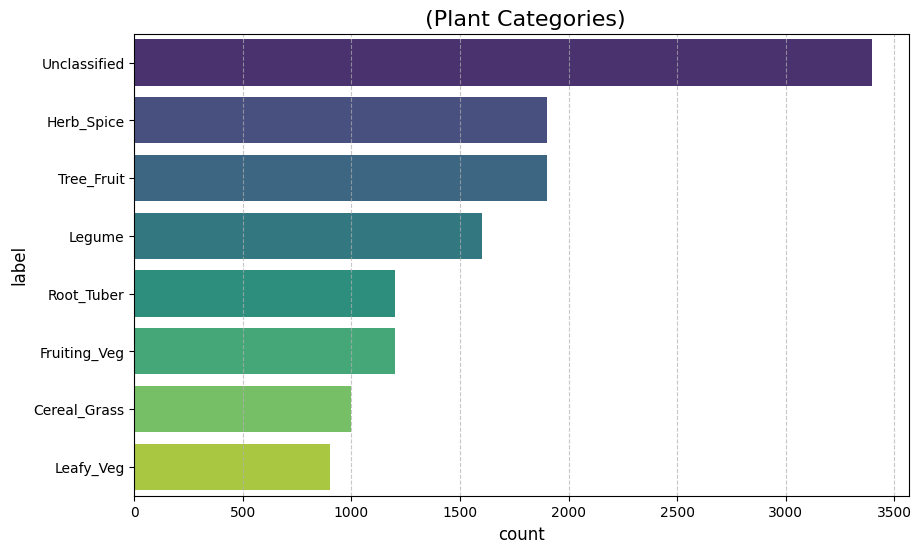

In [80]:
# --- 1.5. تحليل البيانات الاستكشافي (EDA) - توزيع فئات النباتات ---

plt.figure(figsize=(10, 6))
sns.countplot(y='Plant_Category', data=df, order=df['Plant_Category'].value_counts().index, palette='viridis')
plt.title(' (Plant Categories)', fontsize=16)
plt.xlabel('count', fontsize=12)
plt.ylabel('label', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

Histograms

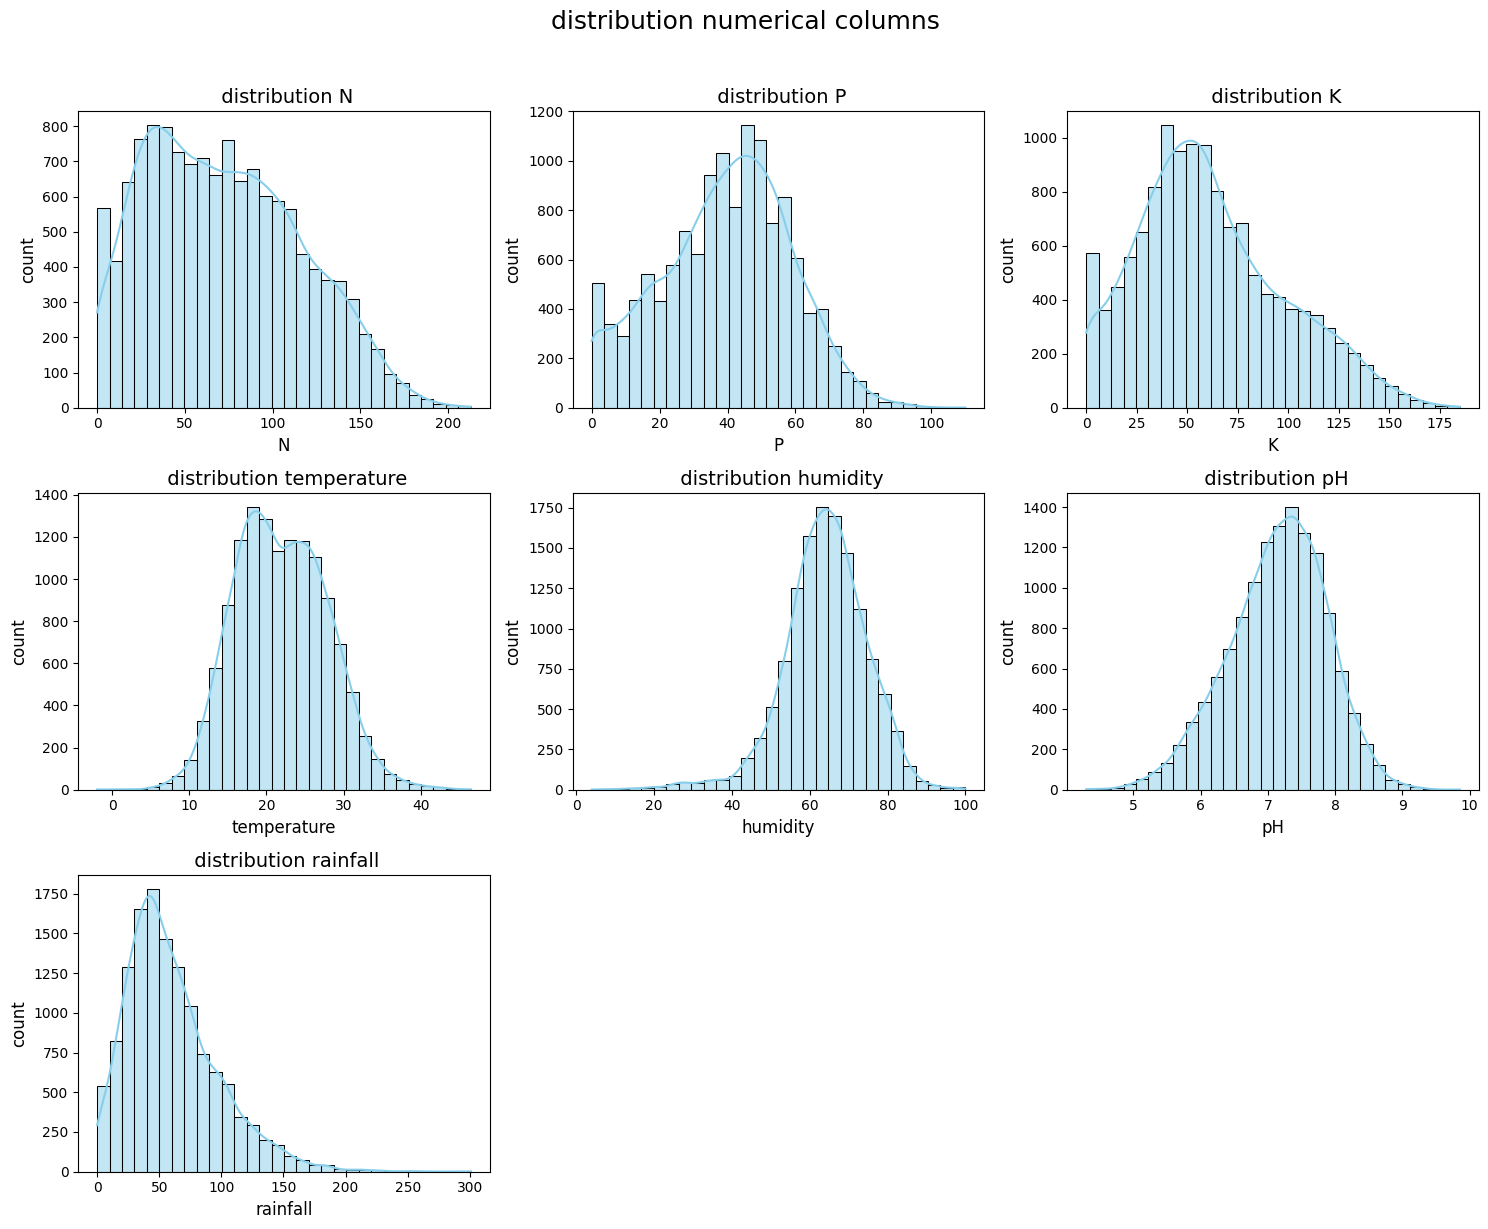

In [81]:

numerical_cols = ['N', 'P', 'K', 'temperature', 'humidity', 'pH', 'rainfall']
df_num = df[numerical_cols]

# Set up the figure size and layout
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 12))
fig.suptitle('distribution numerical columns', fontsize=18, y=1.02)
axes = axes.flatten()

# Plot histograms for each numerical column
for i, col in enumerate(numerical_cols):
    sns.histplot(df_num[col], bins=30, kde=True, ax=axes[i], color='skyblue')
    axes[i].set_title(f' distribution {col}', fontsize=14)
    axes[i].set_xlabel(col, fontsize=12)
    axes[i].set_ylabel('count', fontsize=12)

# Remove unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Box Plots

C:\Users\AFAQE\AppData\Local\Temp\ipykernel_19096\3769752907.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Plant_Category', y=col, data=df, ax=axes[i], palette='Set3')
C:\Users\AFAQE\AppData\Local\Temp\ipykernel_19096\3769752907.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Plant_Category', y=col, data=df, ax=axes[i], palette='Set3')
C:\Users\AFAQE\AppData\Local\Temp\ipykernel_19096\3769752907.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Plant_Category', y=col, data=df, ax=axes[i], palette='Set3')
C:\Users\AFAQ

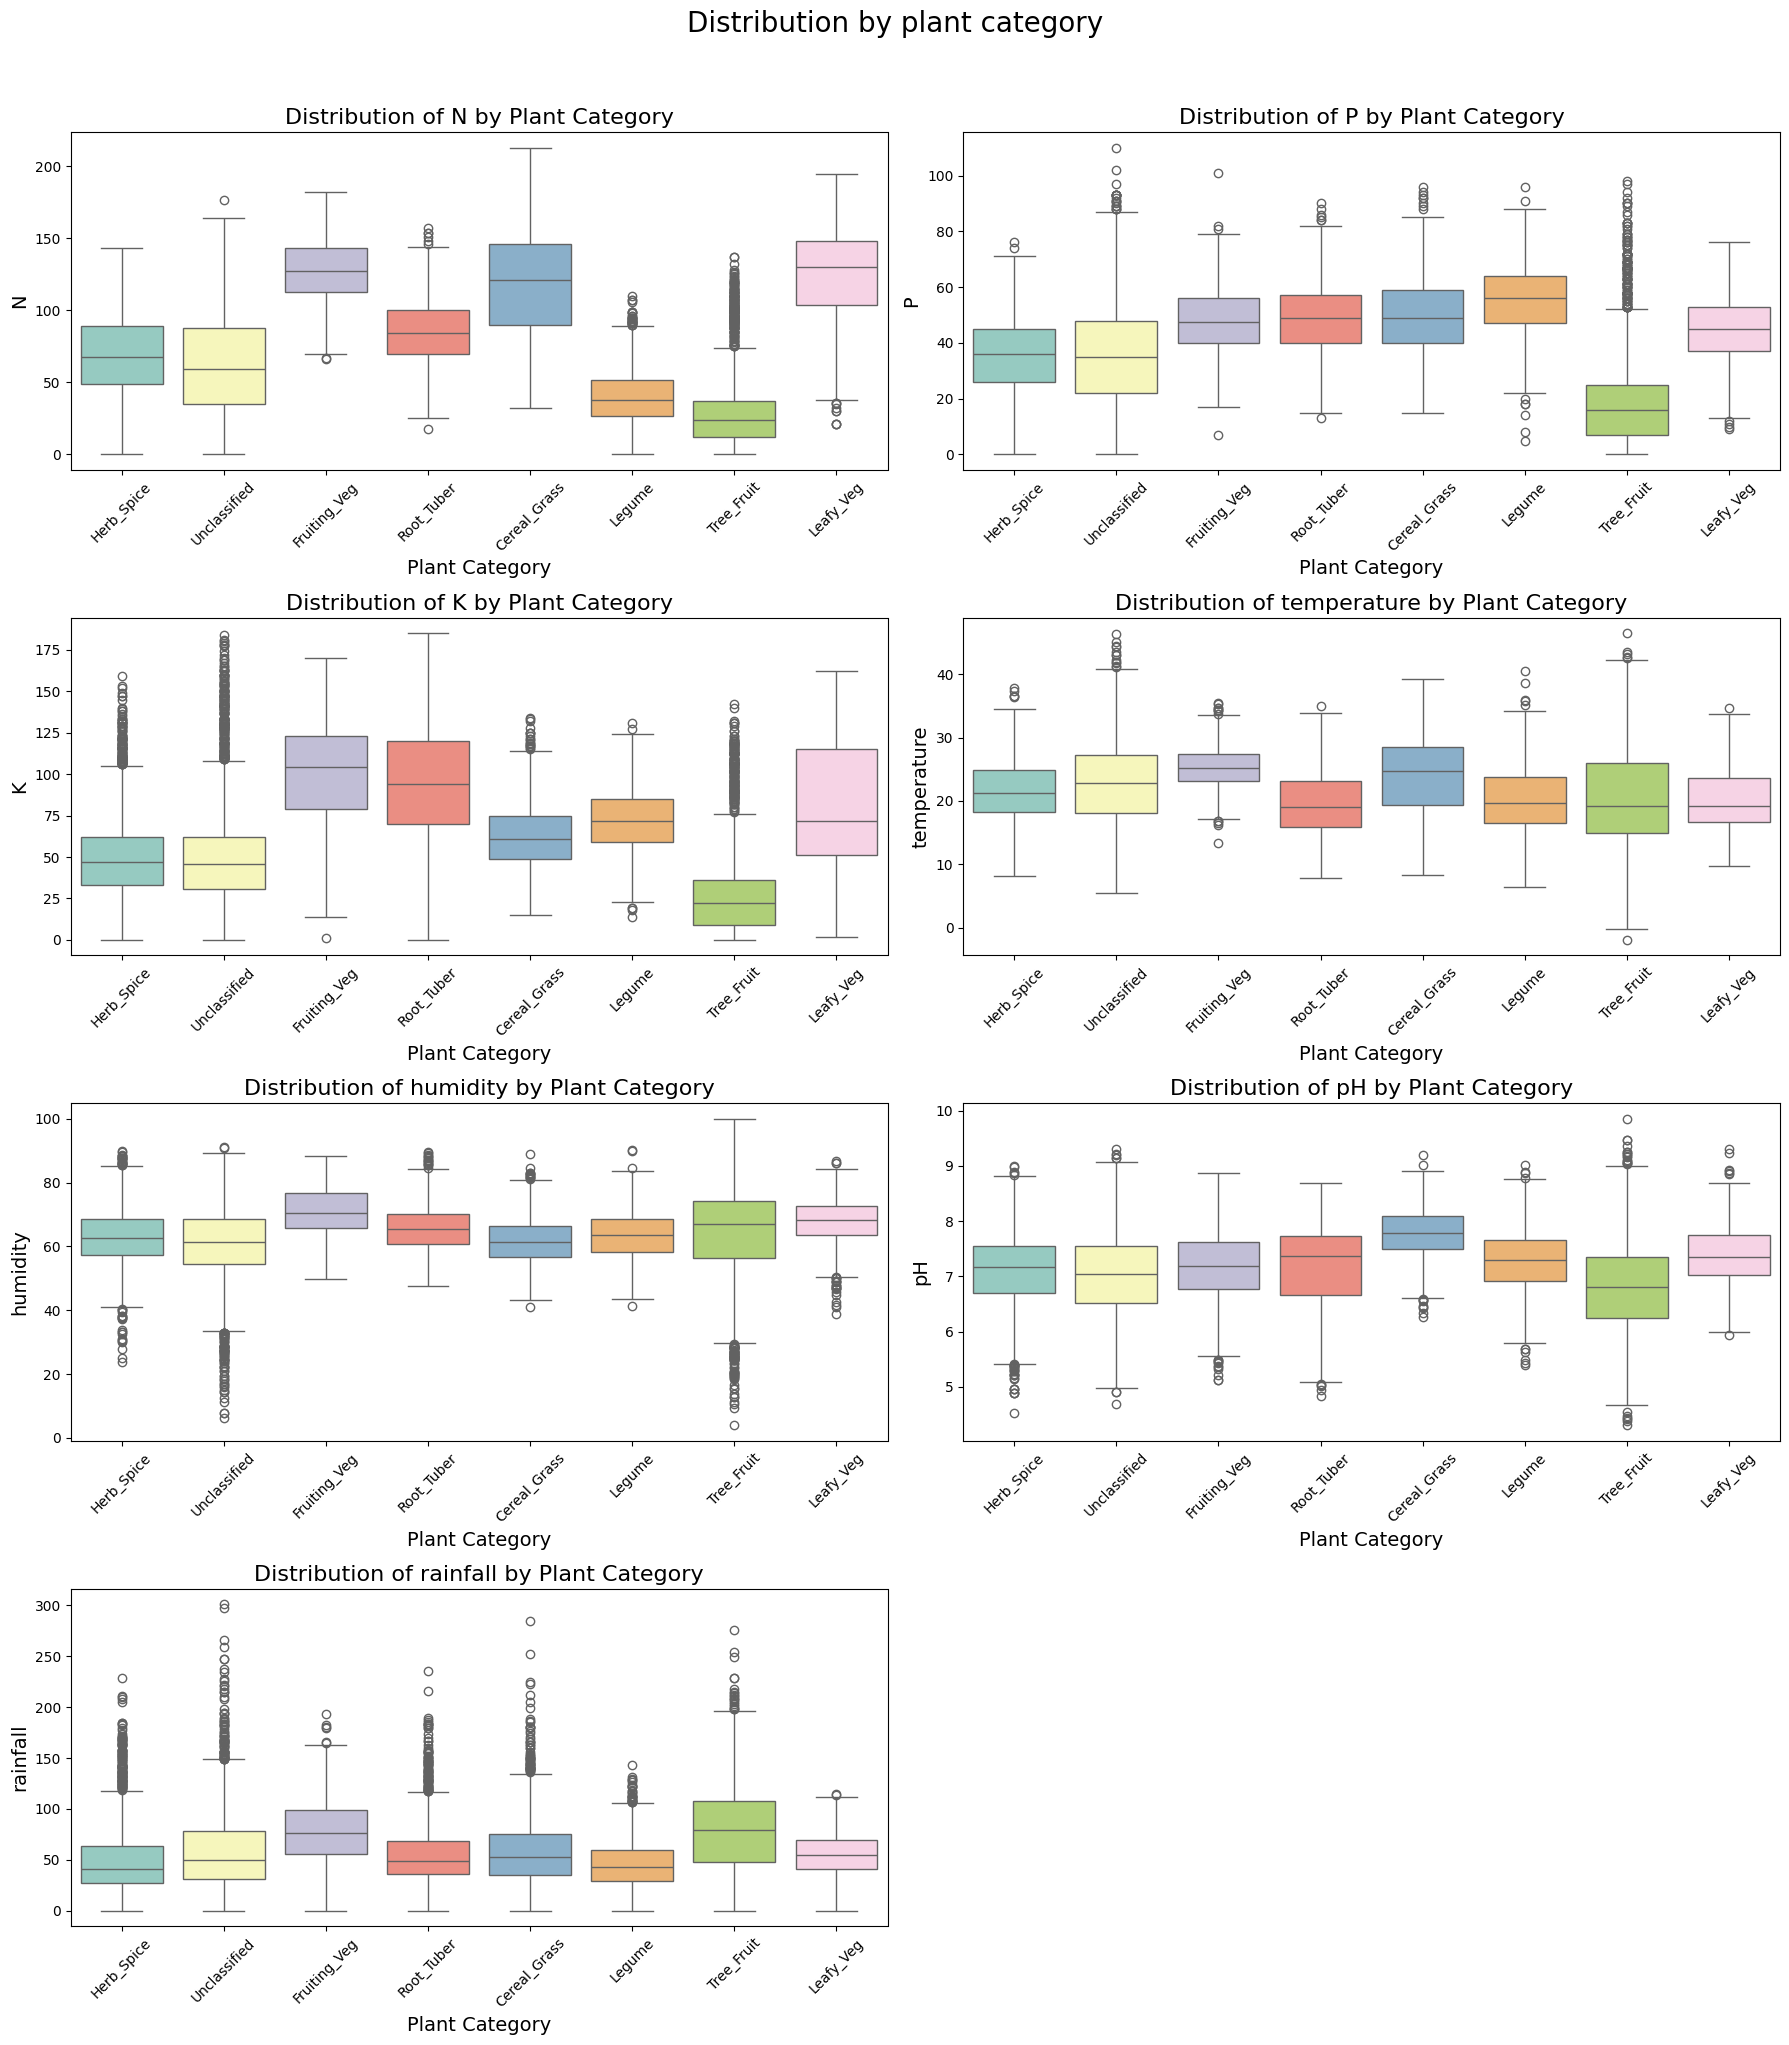

In [82]:

numerical_cols = ['N', 'P', 'K', 'temperature', 'humidity', 'pH', 'rainfall']

# Set up the figure size and layout
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(18, 20))
fig.suptitle('Distribution by plant category', fontsize=20, y=1.02)
axes = axes.flatten()

# Plot box plots for each numerical column against the target
for i, col in enumerate(numerical_cols):
    sns.boxplot(x='Plant_Category', y=col, data=df, ax=axes[i], palette='Set3')
    axes[i].set_title(f'Distribution of {col} by Plant Category', fontsize=16)
    axes[i].set_xlabel('Plant Category', fontsize=14)
    axes[i].set_ylabel(col, fontsize=14)
    axes[i].tick_params(axis='x', rotation=45)

# Remove unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Feature Engineering

In [83]:
# Define features (X) and target (y)
numerical_cols = ['N', 'P', 'K', 'temperature', 'humidity', 'pH', 'rainfall']
X_numerical = df[numerical_cols]
X_categorical = df[['label']] # Plant Name
y = df[TARGET_COLUMN]

In [84]:
# 1. Scale Numerical Features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_numerical)
X_scaled_df = pd.DataFrame(X_scaled, columns=X_numerical.columns, index=X_numerical.index)

In [85]:
# 2. One-Hot Encode Categorical Features (Plant Name)
X_encoded = pd.get_dummies(X_categorical, columns=['label'], prefix='Name', drop_first=True)

In [86]:
# 3. Combine Scaled Numerical and Encoded Categorical Features
X = pd.concat([X_scaled_df, X_encoded], axis=1)

In [87]:
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

In [88]:
print(f"Features prepared. X shape: {X.shape}, y shape: {y_encoded.shape}")

Features prepared. X shape: (13100, 118), y shape: (13100,)


Train model (XGBoost)

In [89]:
# Split data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

In [90]:
# Initialize and train the XGBoost Classifier
model = xgb.XGBClassifier(
    objective='multi:softmax',
    num_class=len(le.classes_),
    n_estimators=500,
    learning_rate=0.05,
    max_depth=7,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='merror',
    random_state=42,
    n_jobs=-1
)

In [91]:
model.fit(X_train, y_train)

C:\Users\AFAQE\AppData\Local\Programs\Python\Python310\lib\site-packages\xgboost\training.py:199: UserWarning: [20:57:24] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='merror',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=7, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=500, n_jobs=-1, num_class=8, ...)

Evaluation

In [92]:
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)


In [93]:
train_acc = accuracy_score(y_train, y_pred_train)
test_acc = accuracy_score(y_test, y_pred_test)

In [94]:
print(f"Train Accuracy: {train_acc * 100:.2f}%")
print(f"Test Accuracy: {test_acc * 100:.2f}%")
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_test, target_names=encoder.classes_))


Train Accuracy: 100.00%
Test Accuracy: 99.96%

Classification Report:

                                  precision    recall  f1-score   support

         Abelmoschus esculentus        1.00      0.95      0.97        20
            Allium ampeloprasum        1.00      1.00      1.00        20
                    Allium cepa        1.00      1.00      1.00        20
                 Allium sativum        1.00      1.00      1.00        20
                     Ammi majus        1.00      1.00      1.00        20
                   Ammi visnaga        1.00      1.00      1.00        20
             Anethum graveolens        1.00      1.00      1.00        20
               Apium graveolens        1.00      1.00      1.00        20
               Arachis hypogaea        1.00      1.00      1.00        40
           Artemisia herba-alba        1.00      1.00      1.00        20
                  Beta vulgaris        1.00      1.00      1.00        20
     Beta vulgaris subsp. cicla        1

Confusion Matrix

In [96]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, X, encoder.transform(y), cv=5, scoring='accuracy')
print("Cross-validation accuracy:", scores)
print("Mean accuracy:", scores.mean() * 100)


C:\Users\AFAQE\AppData\Local\Programs\Python\Python310\lib\site-packages\xgboost\training.py:199: UserWarning: [21:01:19] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\AFAQE\AppData\Local\Programs\Python\Python310\lib\site-packages\xgboost\training.py:199: UserWarning: [21:03:47] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\AFAQE\AppData\Local\Programs\Python\Python310\lib\site-packages\xgboost\training.py:199: UserWarning: [21:06:13] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\AFAQE\AppData\Local\Programs\Python\Python310\lib\site-packages\xgboost\training.py:199: UserWarning: [21:08:35] WARNING: C:\actio

Cross-validation accuracy: [1.         1.         0.99961832 0.99961832 1.        ]
Mean accuracy: 99.9847328244275


In [99]:
# استرجاع الأسماء الأصلية
y_pred_labels = encoder.inverse_transform(y_pred_test)
y_true_labels = encoder.inverse_transform(y_test)

In [100]:
# عرض أول 10 نتائج للمقارنة
results_df = pd.DataFrame({
    'Actual': y_true_labels[:10],
    'Predicted': y_pred_labels[:10]
})

print("\n🔍 مقارنة بين القيم الحقيقية والمتوقعة:")
print(results_df)


🔍 مقارنة بين القيم الحقيقية والمتوقعة:
                     Actual                 Predicted
0       Coriandrum sativum        Coriandrum sativum 
1           Lactuca sativa            Lactuca sativa 
2       Salvia officinalis        Salvia officinalis 
3           Vitis vinifera            Vitis vinifera 
4  Zea mays var. indentata   Zea mays var. indentata 
5        Triticum aestivum         Triticum aestivum 
6      Linum usitatissimum       Linum usitatissimum 
7          Thymus vulgaris           Thymus vulgaris 
8         Raphanus sativus          Raphanus sativus 
9         Prunus domestica          Prunus domestica 


In [102]:
import numpy as np
print("Classes in training:", le.classes_)
print("Unique in y_test:", np.unique(y_test))
print("Unique in y_pred:", np.unique(y_pred))

Classes in training: ['Cereal_Grass' 'Fruiting_Veg' 'Herb_Spice' 'Leafy_Veg' 'Legume'
 'Root_Tuber' 'Tree_Fruit' 'Unclassified']
Unique in y_test: [  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109 110 111]
Unique in y_pred: [0 1 2 3 4 5 6 7]
